# N5 - Overall Analysis

**Objective**: Compare all 16 model variants across 4 training notebooks

**Models**:
- n1: Logistic Regression (4 variants)
- n2: Attention + Logistic Regression (4 variants)
- n3: LightGBM (4 variants)
- n4: Attention + LightGBM (4 variants)

**Analysis**:
1. Overall performance comparison
2. Cross-model paired t-tests
3. Baseline comparison (B1 vs B2)
4. Time feature comparison (is_evening vs hour_sin_cos)
5. Attention vs Non-attention comparison
6. Best model selection

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print(f"Project root: {PROJECT_ROOT}")

Project root: d:\Vietnamese-Fake-News-Detection


In [2]:
# Paths
TRAINED_DIR = PROJECT_ROOT / 'data' / 'trained' / 'early_fusion'
FIGURES_DIR = PROJECT_ROOT / 'data' / 'figures' / 'training'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load All Fold Results

In [3]:
# Model definitions
MODEL_TYPES = {
    'logreg': 'Logistic Regression',
    'attn_logreg': 'Attention + LogReg',
    'lgbm': 'LightGBM',
    'attn_lgbm': 'Attention + LightGBM'
}

VARIANTS = ['B1_is_evening', 'B1_hour_sin_cos', 'B2_is_evening', 'B2_hour_sin_cos']

# Load all results
all_fold_data = {}

for model_type in MODEL_TYPES.keys():
    for variant in VARIANTS:
        file_path = TRAINED_DIR / f'{model_type}_{variant}_folds.csv'
        model_key = f"{model_type}_{variant}"
        
        if file_path.exists():
            df = pd.read_csv(file_path)
            df['model_type'] = model_type
            df['variant'] = variant
            df['baseline'] = int(variant.split('_')[0][1])  # Extract baseline number
            df['time_feature'] = '_'.join(variant.split('_')[1:])  # Extract time feature
            all_fold_data[model_key] = df
            print(f"✓ Loaded: {model_key}")
        else:
            print(f"✗ Missing: {file_path}")

print(f"\nTotal models loaded: {len(all_fold_data)}")

✓ Loaded: logreg_B1_is_evening
✓ Loaded: logreg_B1_hour_sin_cos
✓ Loaded: logreg_B2_is_evening
✓ Loaded: logreg_B2_hour_sin_cos
✓ Loaded: attn_logreg_B1_is_evening
✓ Loaded: attn_logreg_B1_hour_sin_cos
✓ Loaded: attn_logreg_B2_is_evening
✓ Loaded: attn_logreg_B2_hour_sin_cos
✓ Loaded: lgbm_B1_is_evening
✓ Loaded: lgbm_B1_hour_sin_cos
✓ Loaded: lgbm_B2_is_evening
✓ Loaded: lgbm_B2_hour_sin_cos
✓ Loaded: attn_lgbm_B1_is_evening
✓ Loaded: attn_lgbm_B1_hour_sin_cos
✓ Loaded: attn_lgbm_B2_is_evening
✓ Loaded: attn_lgbm_B2_hour_sin_cos

Total models loaded: 16


In [4]:
# Combine all data
combined_df = pd.concat(all_fold_data.values(), ignore_index=True)
combined_df['model_key'] = combined_df['model_type'] + '_' + combined_df['variant']

print(f"Total fold records: {len(combined_df)}")
print(f"\nColumns: {combined_df.columns.tolist()}")

Total fold records: 160

Columns: ['auc', 'f1', 'precision', 'recall', 'threshold', 'fold', 'model_type', 'variant', 'baseline', 'time_feature', 'best_iteration', 'model_key']


## 2. Summary Statistics

In [5]:
# Calculate summary statistics
summary_stats = combined_df.groupby(['model_type', 'variant']).agg({
    'auc': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'threshold': 'mean'
}).round(4)

summary_stats.columns = ['_'.join(col).strip() for col in summary_stats.columns.values]
summary_stats = summary_stats.reset_index()

# Add readable names
summary_stats['Model'] = summary_stats['model_type'].map(MODEL_TYPES)
summary_stats['Baseline'] = summary_stats['variant'].apply(lambda x: int(x.split('_')[0][1]))
summary_stats['Time Feature'] = summary_stats['variant'].apply(lambda x: '_'.join(x.split('_')[1:]))

# Sort by F1 mean descending
summary_stats = summary_stats.sort_values('f1_mean', ascending=False)

display(summary_stats[['Model', 'Baseline', 'Time Feature', 'auc_mean', 'auc_std', 
                       'f1_mean', 'f1_std', 'precision_mean', 'recall_mean']])

,Model,Baseline,Time Feature,auc_mean,auc_std,f1_mean,f1_std,precision_mean,recall_mean
10,LightGBM,2,hour_sin_cos,0.9792,0.0053,0.8851,0.0164,0.8909,0.8811
11,LightGBM,2,is_evening,0.9790,0.0057,0.8837,0.0174,0.8878,0.8823
15,Logistic Regression,2,is_evening,0.9765,0.0072,0.8835,0.0205,0.8711,0.8997
14,Logistic Regression,2,hour_sin_cos,0.9770,0.0068,0.8776,0.0199,0.8738,0.8848
3,Attention + LightGBM,2,is_evening,0.9517,0.0162,0.8629,0.0201,0.8570,0.8724
6,Attention + LogReg,2,hour_sin_cos,0.9574,0.0137,0.8598,0.0252,0.8899,0.8328
2,Attention + LightGBM,2,hour_sin_cos,0.9577,0.0194,0.8561,0.0312,0.8519,0.8625
7,Attention + LogReg,2,is_evening,0.9611,0.0147,0.8506,0.0295,0.8676,0.8366
8,LightGBM,1,hour_sin_cos,0.9440,0.0086,0.7562,0.0304,0.7462,0.7807
9,LightGBM,1,is_evening,0.9437,0.0098,0.7522,0.0259,0.7450,0.7706


In [6]:
# Format for presentation
presentation_df = summary_stats.copy()
presentation_df['AUC'] = presentation_df.apply(lambda x: f"{x['auc_mean']:.4f} ± {x['auc_std']:.4f}", axis=1)
presentation_df['F1'] = presentation_df.apply(lambda x: f"{x['f1_mean']:.4f} ± {x['f1_std']:.4f}", axis=1)
presentation_df['Precision'] = presentation_df.apply(lambda x: f"{x['precision_mean']:.4f} ± {x['precision_std']:.4f}", axis=1)
presentation_df['Recall'] = presentation_df.apply(lambda x: f"{x['recall_mean']:.4f} ± {x['recall_std']:.4f}", axis=1)

final_summary = presentation_df[['Model', 'Baseline', 'Time Feature', 'AUC', 'F1', 'Precision', 'Recall']]
print("\n" + "="*100)
print("ALL MODELS PERFORMANCE SUMMARY")
print("="*100)
display(final_summary)

# Save summary
final_summary.to_csv(TRAINED_DIR / 'overall_summary.csv', index=False)
print(f"\nSaved: {TRAINED_DIR / 'overall_summary.csv'}")


ALL MODELS PERFORMANCE SUMMARY


,Model,Baseline,Time Feature,AUC,F1,Precision,Recall
10,LightGBM,2,hour_sin_cos,0.9792 ± 0.0053,0.8851 ± 0.0164,0.8909 ± 0.0399,0.8811 ± 0.0266
11,LightGBM,2,is_evening,0.9790 ± 0.0057,0.8837 ± 0.0174,0.8878 ± 0.0468,0.8823 ± 0.0305
15,Logistic Regression,2,is_evening,0.9765 ± 0.0072,0.8835 ± 0.0205,0.8711 ± 0.0499,0.8997 ± 0.0400
14,Logistic Regression,2,hour_sin_cos,0.9770 ± 0.0068,0.8776 ± 0.0199,0.8738 ± 0.0535,0.8848 ± 0.0339
3,Attention + LightGBM,2,is_evening,0.9517 ± 0.0162,0.8629 ± 0.0201,0.8570 ± 0.0473,0.8724 ± 0.0430
6,Attention + LogReg,2,hour_sin_cos,0.9574 ± 0.0137,0.8598 ± 0.0252,0.8899 ± 0.0327,0.8328 ± 0.0366
2,Attention + LightGBM,2,hour_sin_cos,0.9577 ± 0.0194,0.8561 ± 0.0312,0.8519 ± 0.0524,0.8625 ± 0.0343
7,Attention + LogReg,2,is_evening,0.9611 ± 0.0147,0.8506 ± 0.0295,0.8676 ± 0.0424,0.8366 ± 0.0453
8,LightGBM,1,hour_sin_cos,0.9440 ± 0.0086,0.7562 ± 0.0304,0.7462 ± 0.0861,0.7807 ± 0.0745
9,LightGBM,1,is_evening,0.9437 ± 0.0098,0.7522 ± 0.0259,0.7450 ± 0.0692,0.7706 ± 0.0754



Saved: d:\Vietnamese-Fake-News-Detection\data\trained\early_fusion\overall_summary.csv


## 3. Performance Visualizations

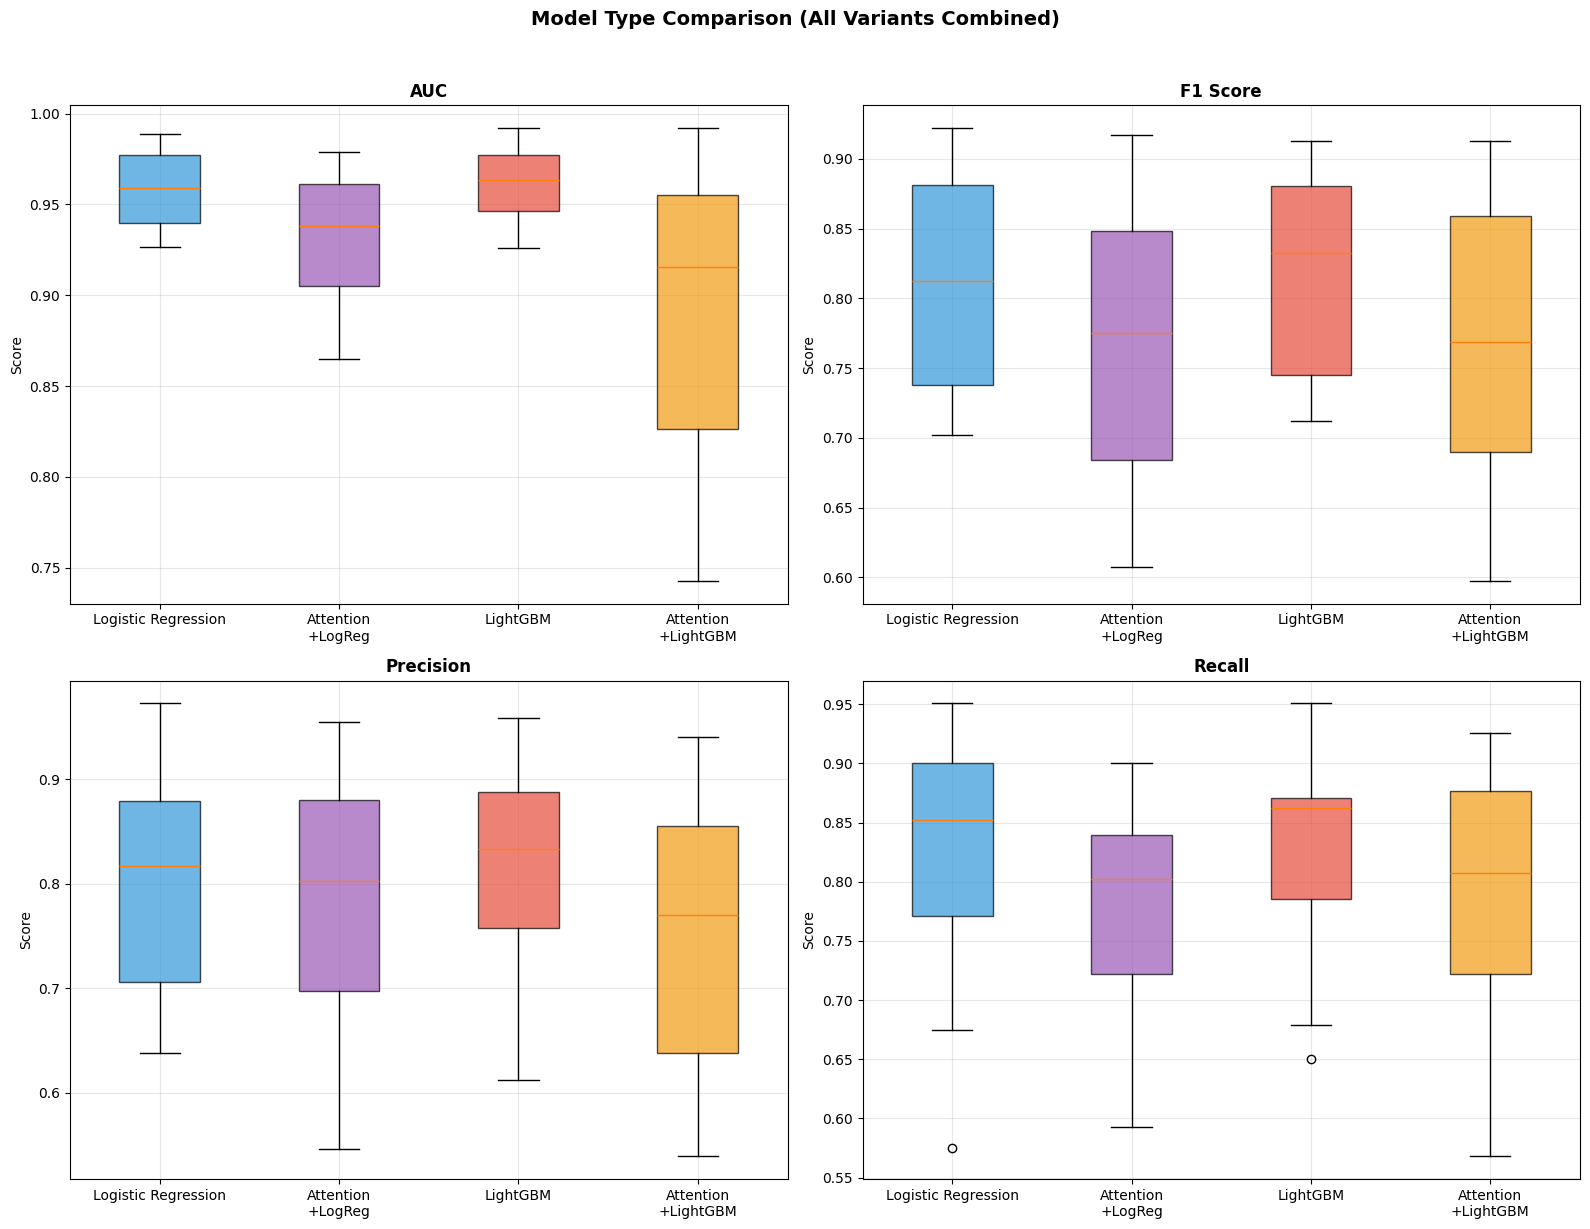

In [7]:
# Overall comparison - Box plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['auc', 'f1', 'precision', 'recall']
titles = ['AUC', 'F1 Score', 'Precision', 'Recall']

for ax, metric, title in zip(axes.flatten(), metrics, titles):
    # Group by model type
    data_by_model = []
    labels = []
    
    for model_type in MODEL_TYPES.keys():
        model_data = combined_df[combined_df['model_type'] == model_type][metric].values
        data_by_model.append(model_data)
        labels.append(MODEL_TYPES[model_type].replace(' + ', '\n+'))
    
    bp = ax.boxplot(data_by_model, labels=labels, patch_artist=True)
    
    colors = ['#3498db', '#9b59b6', '#e74c3c', '#f39c12']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Score')
    ax.grid(True, alpha=0.3)

plt.suptitle('Model Type Comparison (All Variants Combined)', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'overall_model_type_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

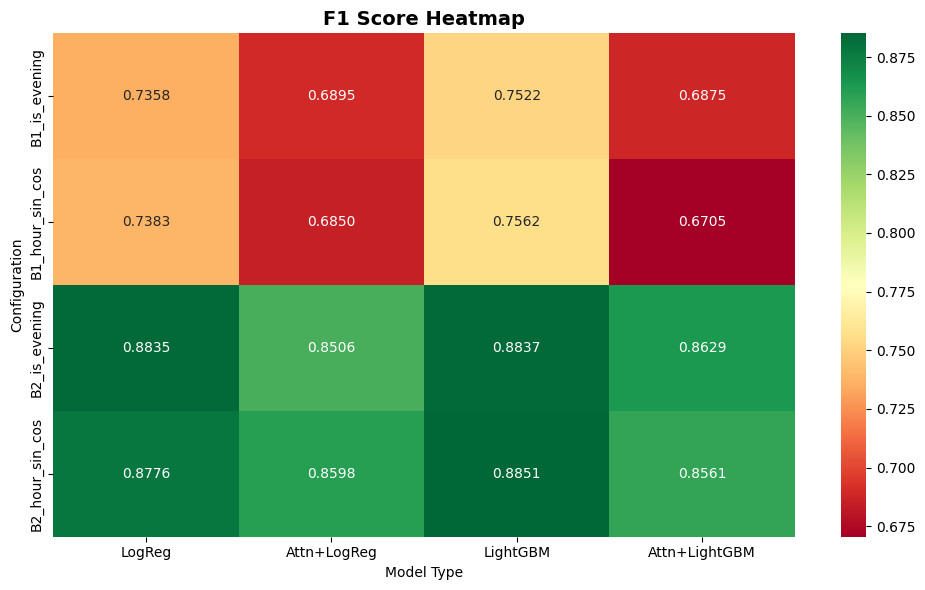

In [8]:
# Heatmap of F1 scores
pivot_f1 = summary_stats.pivot_table(
    index='variant', 
    columns='model_type', 
    values='f1_mean'
)

# Reorder columns and rows
pivot_f1 = pivot_f1[['logreg', 'attn_logreg', 'lgbm', 'attn_lgbm']]
pivot_f1 = pivot_f1.loc[['B1_is_evening', 'B1_hour_sin_cos', 'B2_is_evening', 'B2_hour_sin_cos']]

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='RdYlGn', 
            xticklabels=['LogReg', 'Attn+LogReg', 'LightGBM', 'Attn+LightGBM'],
            yticklabels=['B1_is_evening', 'B1_hour_sin_cos', 'B2_is_evening', 'B2_hour_sin_cos'])
plt.title('F1 Score Heatmap', fontweight='bold', fontsize=14)
plt.xlabel('Model Type')
plt.ylabel('Configuration')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'overall_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

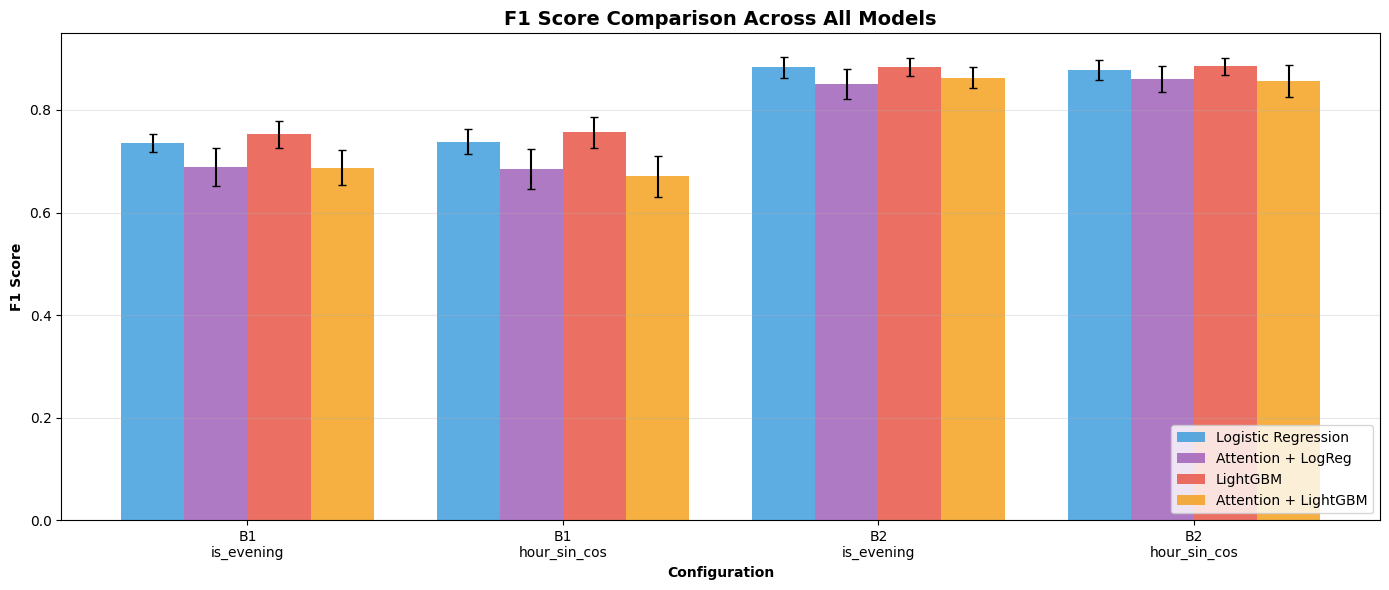

In [9]:
# Bar chart comparison - F1 by model with error bars
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(VARIANTS))
width = 0.2

colors = ['#3498db', '#9b59b6', '#e74c3c', '#f39c12']

for i, (model_type, model_name) in enumerate(MODEL_TYPES.items()):
    model_data = summary_stats[summary_stats['model_type'] == model_type]
    # Ensure order
    model_data = model_data.set_index('variant').loc[VARIANTS].reset_index()
    
    means = model_data['f1_mean'].values
    stds = model_data['f1_std'].values
    
    ax.bar(x + i*width, means, width, yerr=stds, label=model_name, 
           color=colors[i], alpha=0.8, capsize=3)

ax.set_xlabel('Configuration', fontweight='bold')
ax.set_ylabel('F1 Score', fontweight='bold')
ax.set_title('F1 Score Comparison Across All Models', fontweight='bold', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(['B1\nis_evening', 'B1\nhour_sin_cos', 'B2\nis_evening', 'B2\nhour_sin_cos'])
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'overall_f1_bar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Statistical Analysis

In [10]:
def paired_ttest(key1, key2, metric='f1'):
    """Perform paired t-test between two models"""
    if key1 not in all_fold_data or key2 not in all_fold_data:
        return None, None, None
    
    scores1 = all_fold_data[key1][metric].values
    scores2 = all_fold_data[key2][metric].values
    
    t_stat, p_value = stats.ttest_rel(scores1, scores2)
    mean_diff = scores1.mean() - scores2.mean()
    
    return t_stat, p_value, mean_diff

### 4.1 Attention vs Non-Attention

In [11]:
print("="*80)
print("ATTENTION vs NON-ATTENTION COMPARISON (F1 Score)")
print("="*80)

attention_comparisons = [
    ('logreg', 'attn_logreg', 'LogReg vs Attn+LogReg'),
    ('lgbm', 'attn_lgbm', 'LightGBM vs Attn+LightGBM'),
]

attention_results = []

for base_model, attn_model, desc in attention_comparisons:
    print(f"\n{desc}:")
    print("-" * 60)
    
    for variant in VARIANTS:
        key1 = f"{base_model}_{variant}"
        key2 = f"{attn_model}_{variant}"
        
        t_stat, p_value, mean_diff = paired_ttest(key1, key2)
        if t_stat is not None:
            sig = "*" if p_value < 0.05 else ""
            winner = key1 if mean_diff > 0 else key2
            print(f"  {variant}: diff={mean_diff:+.4f}, p={p_value:.4f} {sig}")
            
            attention_results.append({
                'comparison': desc,
                'variant': variant,
                'base_model': base_model,
                'attn_model': attn_model,
                't_stat': t_stat,
                'p_value': p_value,
                'mean_diff': mean_diff,
                'significant': p_value < 0.05,
                'winner': 'attention' if mean_diff < 0 else 'base'
            })

ATTENTION vs NON-ATTENTION COMPARISON (F1 Score)

LogReg vs Attn+LogReg:
------------------------------------------------------------
  B1_is_evening: diff=+0.0463, p=0.0016 *
  B1_hour_sin_cos: diff=+0.0532, p=0.0016 *
  B2_is_evening: diff=+0.0329, p=0.0017 *
  B2_hour_sin_cos: diff=+0.0178, p=0.1216 

LightGBM vs Attn+LightGBM:
------------------------------------------------------------
  B1_is_evening: diff=+0.0646, p=0.0013 *
  B1_hour_sin_cos: diff=+0.0857, p=0.0012 *
  B2_is_evening: diff=+0.0209, p=0.0547 
  B2_hour_sin_cos: diff=+0.0290, p=0.0175 *


### 4.2 Baseline 1 vs Baseline 2

In [12]:
print("\n" + "="*80)
print("BASELINE 1 vs BASELINE 2 COMPARISON (F1 Score)")
print("- Baseline 1: PhoBERT-pretrained + TF-IDF + Handcraft")
print("- Baseline 2: PhoBERT-finetuned + Handcraft")
print("="*80)

baseline_results = []

for model_type, model_name in MODEL_TYPES.items():
    print(f"\n{model_name}:")
    print("-" * 60)
    
    for time_feat in ['is_evening', 'hour_sin_cos']:
        key1 = f"{model_type}_B1_{time_feat}"
        key2 = f"{model_type}_B2_{time_feat}"
        
        t_stat, p_value, mean_diff = paired_ttest(key1, key2)
        if t_stat is not None:
            sig = "*" if p_value < 0.05 else ""
            winner = 'B1' if mean_diff > 0 else 'B2'
            print(f"  {time_feat}: B1-B2 = {mean_diff:+.4f}, p={p_value:.4f} {sig} (winner: {winner})")
            
            baseline_results.append({
                'model_type': model_type,
                'time_feature': time_feat,
                't_stat': t_stat,
                'p_value': p_value,
                'mean_diff': mean_diff,
                'significant': p_value < 0.05,
                'winner': winner
            })


BASELINE 1 vs BASELINE 2 COMPARISON (F1 Score)
- Baseline 1: PhoBERT-pretrained + TF-IDF + Handcraft
- Baseline 2: PhoBERT-finetuned + Handcraft

Logistic Regression:
------------------------------------------------------------
  is_evening: B1-B2 = -0.1477, p=0.0000 * (winner: B2)
  hour_sin_cos: B1-B2 = -0.1393, p=0.0000 * (winner: B2)

Attention + LogReg:
------------------------------------------------------------
  is_evening: B1-B2 = -0.1611, p=0.0000 * (winner: B2)
  hour_sin_cos: B1-B2 = -0.1748, p=0.0000 * (winner: B2)

LightGBM:
------------------------------------------------------------
  is_evening: B1-B2 = -0.1316, p=0.0000 * (winner: B2)
  hour_sin_cos: B1-B2 = -0.1289, p=0.0000 * (winner: B2)

Attention + LightGBM:
------------------------------------------------------------
  is_evening: B1-B2 = -0.1753, p=0.0000 * (winner: B2)
  hour_sin_cos: B1-B2 = -0.1856, p=0.0000 * (winner: B2)


### 4.3 is_evening vs hour_sin_cos

In [13]:
print("\n" + "="*80)
print("TIME FEATURE COMPARISON (F1 Score)")
print("- is_evening: Single binary feature for evening hours")
print("- hour_sin_cos: Cyclic encoding with sin/cos")
print("="*80)

time_feature_results = []

for model_type, model_name in MODEL_TYPES.items():
    print(f"\n{model_name}:")
    print("-" * 60)
    
    for baseline in ['B1', 'B2']:
        key1 = f"{model_type}_{baseline}_is_evening"
        key2 = f"{model_type}_{baseline}_hour_sin_cos"
        
        t_stat, p_value, mean_diff = paired_ttest(key1, key2)
        if t_stat is not None:
            sig = "*" if p_value < 0.05 else ""
            winner = 'is_evening' if mean_diff > 0 else 'hour_sin_cos'
            print(f"  {baseline}: evening-sincos = {mean_diff:+.4f}, p={p_value:.4f} {sig} (winner: {winner})")
            
            time_feature_results.append({
                'model_type': model_type,
                'baseline': baseline,
                't_stat': t_stat,
                'p_value': p_value,
                'mean_diff': mean_diff,
                'significant': p_value < 0.05,
                'winner': winner
            })


TIME FEATURE COMPARISON (F1 Score)
- is_evening: Single binary feature for evening hours
- hour_sin_cos: Cyclic encoding with sin/cos

Logistic Regression:
------------------------------------------------------------
  B1: evening-sincos = -0.0025, p=0.3942  (winner: hour_sin_cos)
  B2: evening-sincos = +0.0059, p=0.0672  (winner: is_evening)

Attention + LogReg:
------------------------------------------------------------
  B1: evening-sincos = +0.0045, p=0.7460  (winner: is_evening)
  B2: evening-sincos = -0.0092, p=0.2727  (winner: hour_sin_cos)

LightGBM:
------------------------------------------------------------
  B1: evening-sincos = -0.0041, p=0.3548  (winner: hour_sin_cos)
  B2: evening-sincos = -0.0014, p=0.5893  (winner: hour_sin_cos)

Attention + LightGBM:
------------------------------------------------------------
  B1: evening-sincos = +0.0170, p=0.0907  (winner: is_evening)
  B2: evening-sincos = +0.0068, p=0.3226  (winner: is_evening)


### 4.4 Cross-Model Type Comparison

In [14]:
print("\n" + "="*80)
print("CROSS-MODEL TYPE COMPARISON (F1 Score)")
print("="*80)

cross_model_comparisons = [
    ('logreg', 'lgbm', 'LogReg vs LightGBM'),
    ('attn_logreg', 'attn_lgbm', 'Attn+LogReg vs Attn+LightGBM'),
]

cross_model_results = []

for model1, model2, desc in cross_model_comparisons:
    print(f"\n{desc}:")
    print("-" * 60)
    
    for variant in VARIANTS:
        key1 = f"{model1}_{variant}"
        key2 = f"{model2}_{variant}"
        
        t_stat, p_value, mean_diff = paired_ttest(key1, key2)
        if t_stat is not None:
            sig = "*" if p_value < 0.05 else ""
            winner = model1 if mean_diff > 0 else model2
            print(f"  {variant}: diff={mean_diff:+.4f}, p={p_value:.4f} {sig} (winner: {winner})")
            
            cross_model_results.append({
                'comparison': desc,
                'variant': variant,
                'model1': model1,
                'model2': model2,
                't_stat': t_stat,
                'p_value': p_value,
                'mean_diff': mean_diff,
                'significant': p_value < 0.05,
                'winner': winner
            })


CROSS-MODEL TYPE COMPARISON (F1 Score)

LogReg vs LightGBM:
------------------------------------------------------------
  B1_is_evening: diff=-0.0164, p=0.0905  (winner: lgbm)
  B1_hour_sin_cos: diff=-0.0180, p=0.1362  (winner: lgbm)
  B2_is_evening: diff=-0.0002, p=0.9582  (winner: lgbm)
  B2_hour_sin_cos: diff=-0.0075, p=0.0658  (winner: lgbm)

Attn+LogReg vs Attn+LightGBM:
------------------------------------------------------------
  B1_is_evening: diff=+0.0020, p=0.8524  (winner: attn_logreg)
  B1_hour_sin_cos: diff=+0.0145, p=0.1101  (winner: attn_logreg)
  B2_is_evening: diff=-0.0123, p=0.0895  (winner: attn_lgbm)
  B2_hour_sin_cos: diff=+0.0037, p=0.5296  (winner: attn_logreg)


## 5. Best Model Analysis

In [15]:
# Find best model by F1
best_row = summary_stats.loc[summary_stats['f1_mean'].idxmax()]

print("="*80)
print("BEST MODEL BY F1 SCORE")
print("="*80)
print(f"\nModel Type: {MODEL_TYPES[best_row['model_type']]}")
print(f"Variant: {best_row['variant']}")
print(f"Baseline: {best_row['Baseline']}")
print(f"Time Feature: {best_row['Time Feature']}")
print(f"\nPerformance:")
print(f"  AUC:       {best_row['auc_mean']:.4f} ± {best_row['auc_std']:.4f}")
print(f"  F1:        {best_row['f1_mean']:.4f} ± {best_row['f1_std']:.4f}")
print(f"  Precision: {best_row['precision_mean']:.4f} ± {best_row['precision_std']:.4f}")
print(f"  Recall:    {best_row['recall_mean']:.4f} ± {best_row['recall_std']:.4f}")

BEST MODEL BY F1 SCORE

Model Type: LightGBM
Variant: B2_hour_sin_cos
Baseline: 2
Time Feature: hour_sin_cos

Performance:
  AUC:       0.9792 ± 0.0053
  F1:        0.8851 ± 0.0164
  Precision: 0.8909 ± 0.0399
  Recall:    0.8811 ± 0.0266


In [16]:
# Top 5 models
print("\n" + "="*80)
print("TOP 5 MODELS BY F1 SCORE")
print("="*80 + "\n")

top5 = summary_stats.nlargest(5, 'f1_mean')
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"{i}. {MODEL_TYPES[row['model_type']]} - {row['variant']}")
    print(f"   F1: {row['f1_mean']:.4f} ± {row['f1_std']:.4f}, AUC: {row['auc_mean']:.4f}")


TOP 5 MODELS BY F1 SCORE

1. LightGBM - B2_hour_sin_cos
   F1: 0.8851 ± 0.0164, AUC: 0.9792
2. LightGBM - B2_is_evening
   F1: 0.8837 ± 0.0174, AUC: 0.9790
3. Logistic Regression - B2_is_evening
   F1: 0.8835 ± 0.0205, AUC: 0.9765
4. Logistic Regression - B2_hour_sin_cos
   F1: 0.8776 ± 0.0199, AUC: 0.9770
5. Attention + LightGBM - B2_is_evening
   F1: 0.8629 ± 0.0201, AUC: 0.9517


In [17]:
# Statistical comparison with best model
best_key = f"{best_row['model_type']}_{best_row['variant']}"

print("\n" + "="*80)
print(f"PAIRED T-TEST: BEST MODEL vs OTHERS")
print(f"Best Model: {best_key}")
print("="*80)

comparison_with_best = []

for model_key in all_fold_data.keys():
    if model_key == best_key:
        continue
    
    t_stat, p_value, mean_diff = paired_ttest(best_key, model_key)
    if t_stat is not None:
        sig = "*" if p_value < 0.05 else ""
        significant = "Yes" if p_value < 0.05 else "No"
        
        comparison_with_best.append({
            'model': model_key,
            't_stat': t_stat,
            'p_value': p_value,
            'mean_diff': mean_diff,
            'significant': significant
        })

comparison_df = pd.DataFrame(comparison_with_best)
comparison_df = comparison_df.sort_values('mean_diff', ascending=False)

print(f"\n(Positive diff means best model is better)\n")
display(comparison_df)


PAIRED T-TEST: BEST MODEL vs OTHERS
Best Model: lgbm_B2_hour_sin_cos

(Positive diff means best model is better)



,model,t_stat,p_value,mean_diff,significant
12,attn_lgbm_B1_hour_sin_cos,17.864257,2.452367e-08,0.214610,Yes
5,attn_logreg_B1_hour_sin_cos,17.246608,3.338614e-08,0.200089,Yes
11,attn_lgbm_B1_is_evening,16.602289,4.658672e-08,0.197585,Yes
4,attn_logreg_B1_is_evening,13.525544,2.761379e-07,0.195577,Yes
0,logreg_B1_is_evening,19.202825,1.299378e-08,0.149308,Yes
1,logreg_B1_hour_sin_cos,17.308757,3.235048e-08,0.146844,Yes
8,lgbm_B1_is_evening,14.270211,1.738355e-07,0.132951,Yes
9,lgbm_B1_hour_sin_cos,10.630532,2.146152e-06,0.128871,Yes
6,attn_logreg_B2_is_evening,4.427784,1.652450e-03,0.034523,Yes
14,attn_lgbm_B2_hour_sin_cos,2.901979,1.753876e-02,0.029038,Yes


## 6. Summary Visualization

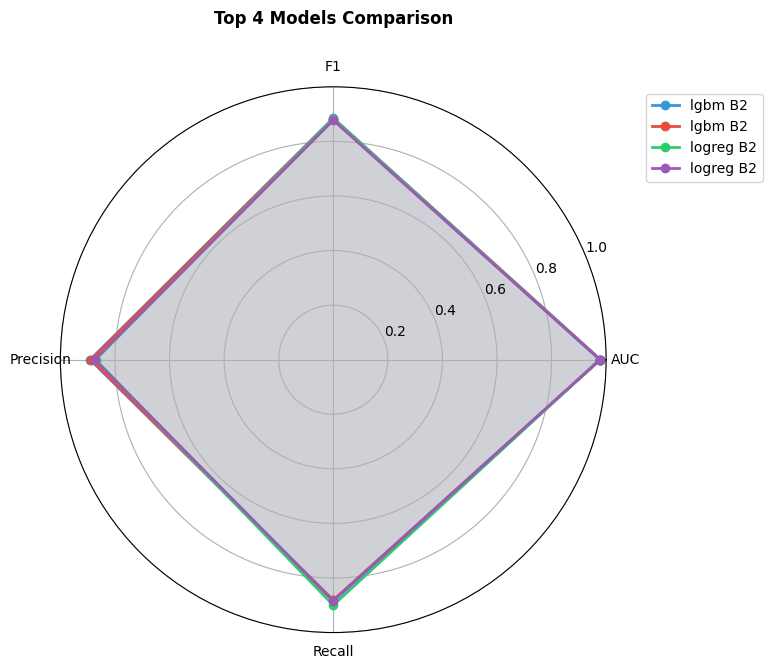

In [18]:
# Radar chart for top models
from math import pi

top4 = summary_stats.nlargest(4, 'f1_mean')
metrics_radar = ['auc_mean', 'f1_mean', 'precision_mean', 'recall_mean']
metric_labels = ['AUC', 'F1', 'Precision', 'Recall']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

angles = [n / float(len(metrics_radar)) * 2 * pi for n in range(len(metrics_radar))]
angles += angles[:1]

colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

for i, (_, row) in enumerate(top4.iterrows()):
    values = [row[m] for m in metrics_radar]
    values += values[:1]
    
    label = f"{row['model_type']}_{row['variant'][:2]}".replace('_', ' ')
    ax.plot(angles, values, 'o-', linewidth=2, label=label, color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.title('Top 4 Models Comparison', fontweight='bold', fontsize=12, y=1.1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'overall_top4_radar.png', dpi=150, bbox_inches='tight')
plt.show()

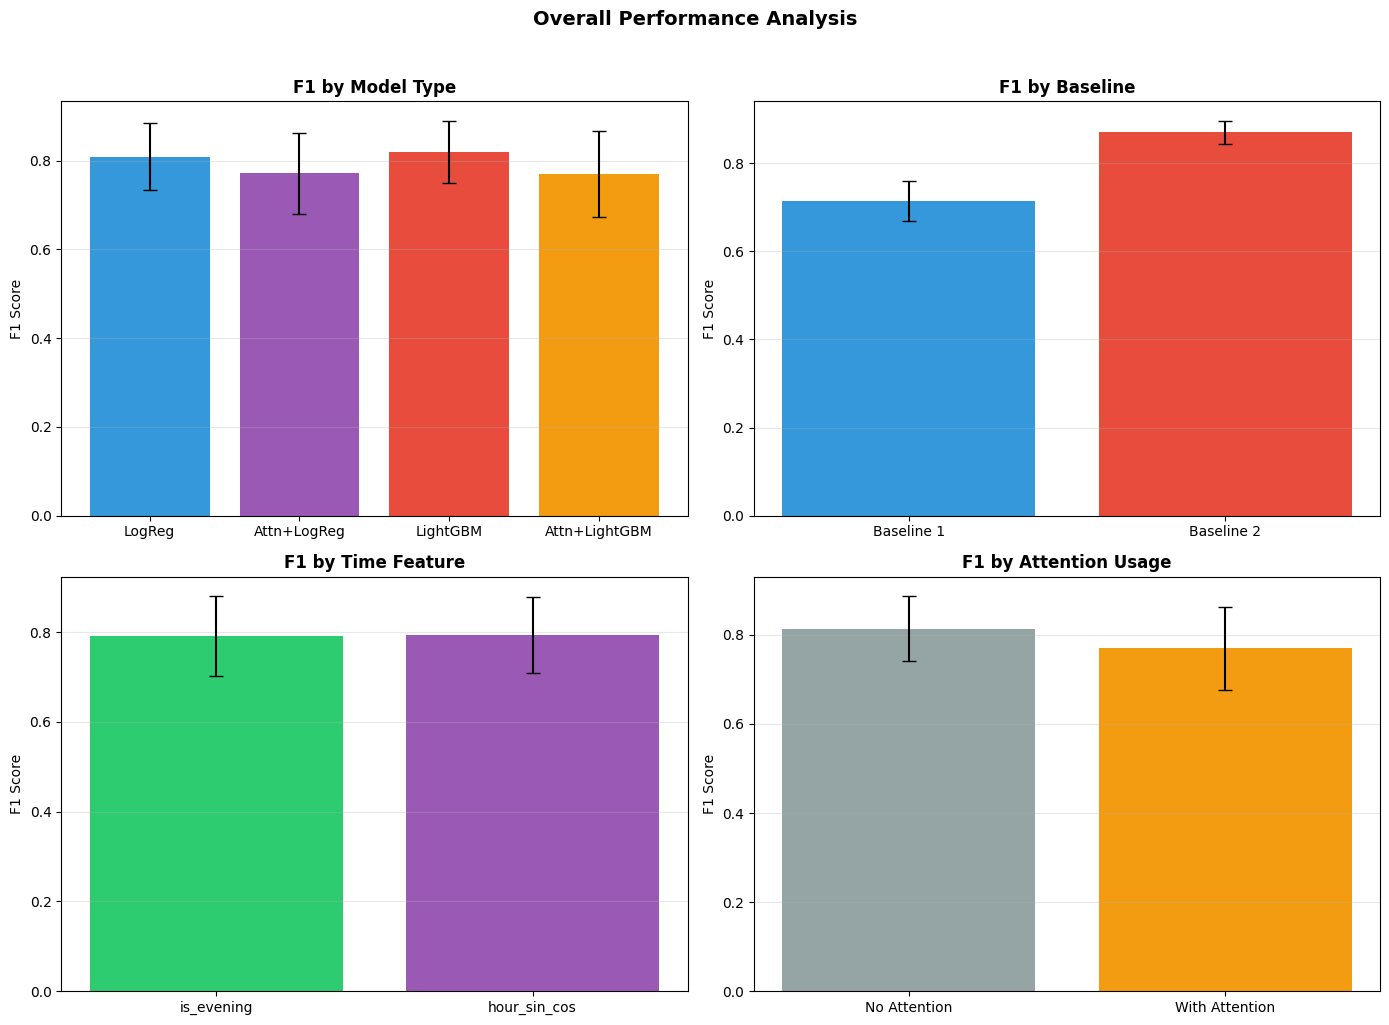

In [19]:
# Final summary plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. By Model Type
ax = axes[0, 0]
type_summary = combined_df.groupby('model_type')['f1'].agg(['mean', 'std'])
type_summary = type_summary.reindex(['logreg', 'attn_logreg', 'lgbm', 'attn_lgbm'])
bars = ax.bar(range(len(type_summary)), type_summary['mean'], 
              yerr=type_summary['std'], capsize=5, 
              color=['#3498db', '#9b59b6', '#e74c3c', '#f39c12'])
ax.set_xticks(range(len(type_summary)))
ax.set_xticklabels(['LogReg', 'Attn+LogReg', 'LightGBM', 'Attn+LightGBM'])
ax.set_title('F1 by Model Type', fontweight='bold')
ax.set_ylabel('F1 Score')
ax.grid(True, alpha=0.3, axis='y')

# 2. By Baseline
ax = axes[0, 1]
baseline_summary = combined_df.groupby('baseline')['f1'].agg(['mean', 'std'])
bars = ax.bar(['Baseline 1', 'Baseline 2'], baseline_summary['mean'], 
              yerr=baseline_summary['std'], capsize=5,
              color=['#3498db', '#e74c3c'])
ax.set_title('F1 by Baseline', fontweight='bold')
ax.set_ylabel('F1 Score')
ax.grid(True, alpha=0.3, axis='y')

# 3. By Time Feature
ax = axes[1, 0]
time_summary = combined_df.groupby('time_feature')['f1'].agg(['mean', 'std'])
bars = ax.bar(['is_evening', 'hour_sin_cos'], time_summary['mean'], 
              yerr=time_summary['std'], capsize=5,
              color=['#2ecc71', '#9b59b6'])
ax.set_title('F1 by Time Feature', fontweight='bold')
ax.set_ylabel('F1 Score')
ax.grid(True, alpha=0.3, axis='y')

# 4. Attention Effect
ax = axes[1, 1]
combined_df['has_attention'] = combined_df['model_type'].str.contains('attn')
attn_summary = combined_df.groupby('has_attention')['f1'].agg(['mean', 'std'])
bars = ax.bar(['No Attention', 'With Attention'], attn_summary['mean'], 
              yerr=attn_summary['std'], capsize=5,
              color=['#95a5a6', '#f39c12'])
ax.set_title('F1 by Attention Usage', fontweight='bold')
ax.set_ylabel('F1 Score')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Overall Performance Analysis', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'overall_summary_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save All Statistical Results

In [20]:
# Save all statistical results
if attention_results:
    pd.DataFrame(attention_results).to_csv(
        TRAINED_DIR / 'overall_attention_comparison.csv', index=False)

if baseline_results:
    pd.DataFrame(baseline_results).to_csv(
        TRAINED_DIR / 'overall_baseline_comparison.csv', index=False)

if time_feature_results:
    pd.DataFrame(time_feature_results).to_csv(
        TRAINED_DIR / 'overall_timefeature_comparison.csv', index=False)

if cross_model_results:
    pd.DataFrame(cross_model_results).to_csv(
        TRAINED_DIR / 'overall_crossmodel_comparison.csv', index=False)

if comparison_with_best:
    comparison_df.to_csv(
        TRAINED_DIR / 'overall_best_model_comparison.csv', index=False)

print(f"Statistical results saved to: {TRAINED_DIR}")

Statistical results saved to: d:\Vietnamese-Fake-News-Detection\data\trained\early_fusion


## 8. Conclusions

In [21]:
print("="*80)
print("OVERALL ANALYSIS CONCLUSIONS")
print("="*80)

print(f"\n📊 Total Models Compared: {len(all_fold_data)}")

print(f"\n🏆 Best Model: {best_key}")
print(f"   F1: {best_row['f1_mean']:.4f} ± {best_row['f1_std']:.4f}")
print(f"   AUC: {best_row['auc_mean']:.4f}")

# Model type winner
type_winner = combined_df.groupby('model_type')['f1'].mean().idxmax()
print(f"\n📈 Best Model Type: {MODEL_TYPES[type_winner]}")

# Baseline winner
baseline_winner = combined_df.groupby('baseline')['f1'].mean().idxmax()
print(f"📈 Best Baseline: Baseline {baseline_winner}")

# Time feature winner
time_winner = combined_df.groupby('time_feature')['f1'].mean().idxmax()
print(f"📈 Best Time Feature: {time_winner}")

# Attention effect
attn_effect = combined_df.groupby('has_attention')['f1'].mean()
attn_improvement = attn_effect[True] - attn_effect[False]
print(f"\n🔍 Attention Effect: {attn_improvement:+.4f} F1")

print(f"\n📁 Output files saved to:")
print(f"   {TRAINED_DIR}")
print(f"   {FIGURES_DIR}")

OVERALL ANALYSIS CONCLUSIONS

📊 Total Models Compared: 16

🏆 Best Model: lgbm_B2_hour_sin_cos
   F1: 0.8851 ± 0.0164
   AUC: 0.9792

📈 Best Model Type: LightGBM
📈 Best Baseline: Baseline 2
📈 Best Time Feature: is_evening

🔍 Attention Effect: -0.0438 F1

📁 Output files saved to:
   d:\Vietnamese-Fake-News-Detection\data\trained\early_fusion
   d:\Vietnamese-Fake-News-Detection\data\figures\training
